# Exploring the Bloch Sphere with Qiskit

## Lab Activity

This notebook is designed to help you understand the **Bloch Sphere** through short explanations, guided code tasks, and reflection questions.

### Learning goals
By the end of this activity, you should be able to:
- identify where $|0\rangle$ and $|1\rangle$ lie on the Bloch Sphere
- explain how a point on the Bloch Sphere represents a single-qubit state
- use **Qiskit** to visualize Bloch vectors and statevectors
- predict how basic quantum gates move a qubit on the Bloch Sphere

### Instructions
Work through the notebook in order. For each task:
1. **Read** the short explanation.
2. **Predict** what will happen.
3. **Run** the code.
4. **Write** your answer in the reflection cells.

> This activity focuses on **single-qubit states**, where the Bloch Sphere is most useful.


## Part 1: Warm-up

Before running any code, discuss or think about these questions:

1. Where is the state $|0\rangle$ on the Bloch Sphere?
2. Where is the state $|1\rangle$ on the Bloch Sphere?
3. What kind of state do you get after applying a Hadamard gate to $|0\rangle$?
4. Why is the Bloch Sphere mainly used for one qubit?

Write a short answer below.


In [ ]:
# Write your warm-up response here.


## Part 2: Import the required libraries

In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_vector, plot_bloch_multivector


## Part 3: Visualizing basis states

A Bloch vector is written as **[x, y, z]** in Cartesian coordinates.

- $|0\rangle$ is at the **north pole**
- $|1\rangle$ is at the **south pole**

### Task 1
Run the code below and observe the plots.


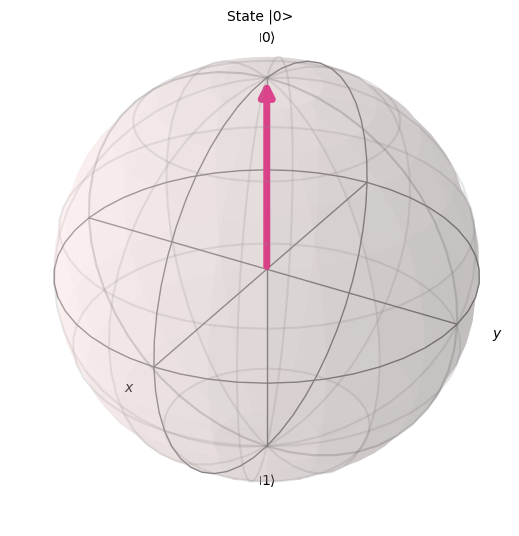

In [2]:
plot_bloch_vector([0, 0, 1], title="State |0>")


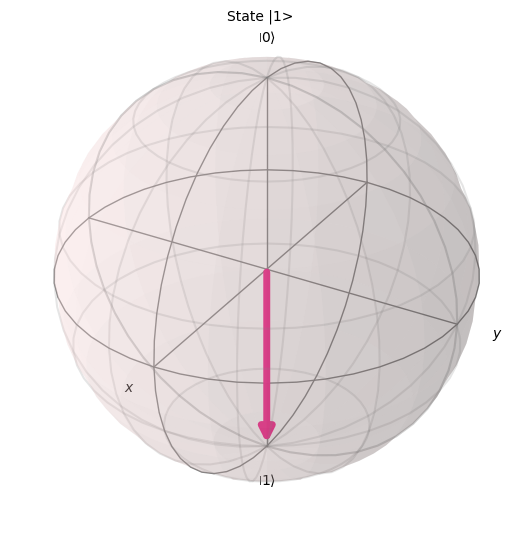

In [3]:
plot_bloch_vector([0, 0, -1], title="State |1>")


### Reflection
1. Why is $|0\rangle$ at the top of the sphere?
2. Why is $|1\rangle$ at the bottom?
3. What does the **z-axis** represent here?


In [ ]:
# Write your reflections for Task 1 here.


## Part 4: A point on the equator

The equator of the Bloch Sphere represents superposition states with equal probabilities of measuring $|0\rangle$ and $|1\rangle$.

### Task 2
Run the code below to plot a point on the **y-axis**.


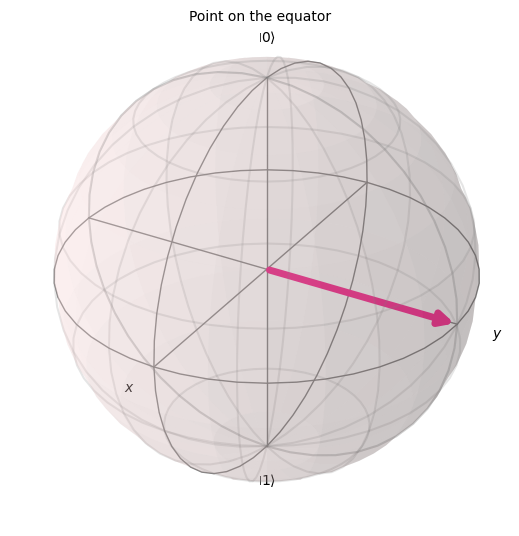

In [4]:
plot_bloch_vector([0, 1, 0], title="Point on the equator")


### Reflection
1. Is this state at a pole or on the equator?
2. What does its position suggest about the qubit?


In [ ]:
# Write your reflections for Task 2 here.


## Part 5: Using spherical coordinates

Instead of Cartesian coordinates, the Bloch Sphere can also be described using spherical coordinates:

- $r$ = radius
- $\theta$ = angle from the positive z-axis
- $\phi$ = angle around the z-axis

### Task 3
Plot a state using spherical coordinates.


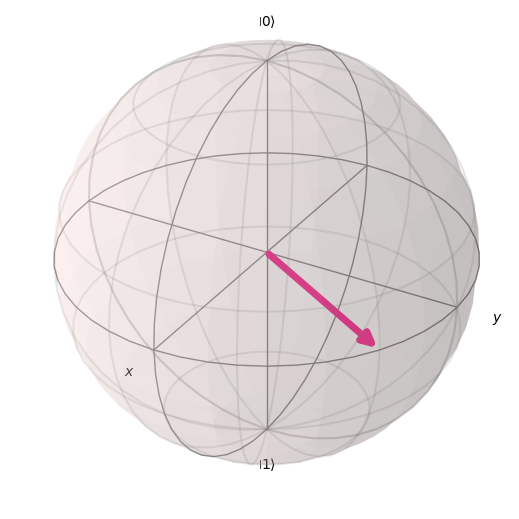

In [13]:
plot_bloch_vector([1, np.pi/2, np.pi/3], coord_type='spherical')


### Reflection
1. What happens when $\theta = \pi/2$?
2. What role does $\phi$ play?
3. Why is the radius equal to 1 for a pure state?


In [ ]:
# Write your reflections for Task 3 here.


## Part 6: Convert spherical coordinates to Cartesian coordinates

### Task 4
Run the code below to convert spherical coordinates into Cartesian coordinates.


In [6]:
# Define the spherical coordinates
r = 1
theta = np.pi/2
phi = np.pi/3

# Convert spherical to Cartesian coordinates
x = r * np.sin(theta) * np.cos(phi)
y = r * np.sin(theta) * np.sin(phi)
z = r * np.cos(theta)

print("x =", x)
print("y =", y)
print("z =", z)


x = 0.5000000000000001
y = 0.8660254037844386
z = 6.123233995736766e-17


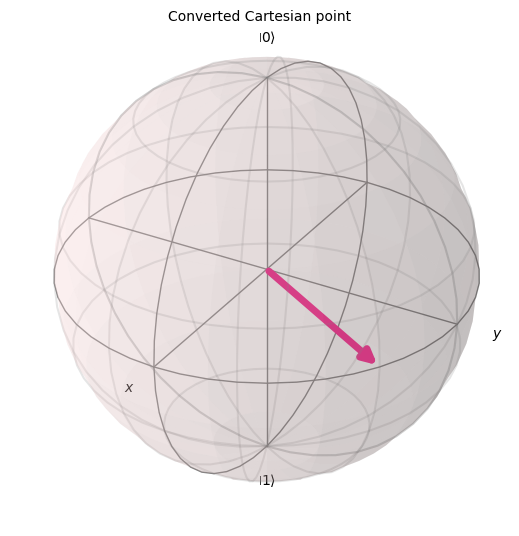

In [7]:
plot_bloch_vector([x, y, z], title="Converted Cartesian point")


### Reflection
1. How do the Cartesian coordinates relate to the plotted point?
2. If you change $\theta$ to 0, where will the point move?
3. If you change $\theta$ to $\pi$, where will the point move?


In [ ]:
# Write your reflections for Task 4 here.


## Part 7: Visualizing quantum states from circuits

Now we move from manually plotting points to creating qubit states with quantum circuits.

We will use:
- `QuantumCircuit`
- `Statevector`
- `plot_bloch_multivector`

### Note
Although `plot_bloch_multivector` can show multiple qubits, in this activity we will mostly use **one qubit** so the movement is easier to understand.


## Part 8: Apply the Hadamard gate

The **Hadamard gate** takes $|0\rangle$ into a superposition state.

### Task 5
Before running the cell:
- Predict whether the final state will be at a pole or on the equator.


   ┌───┐
q: ┤ H ├
   └───┘


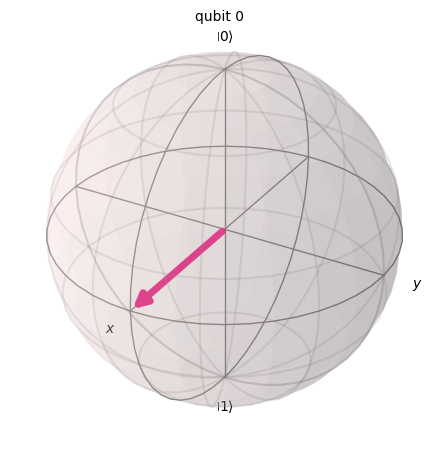

In [15]:
qc = QuantumCircuit(1)
qc.h(0)

print(qc)

state = Statevector.from_instruction(qc)
plot_bloch_multivector(state)


### Reflection
1. Where did the state move?
2. Why is the state no longer at the north pole?
3. What does this tell you about superposition?


In [ ]:
# Write your reflections for Task 5 here.


## Part 9: Apply the X gate

The **X gate** flips $|0\rangle$ to $|1\rangle$.

### Task 6
Predict what will happen before running the code.


   ┌───┐
q: ┤ X ├
   └───┘


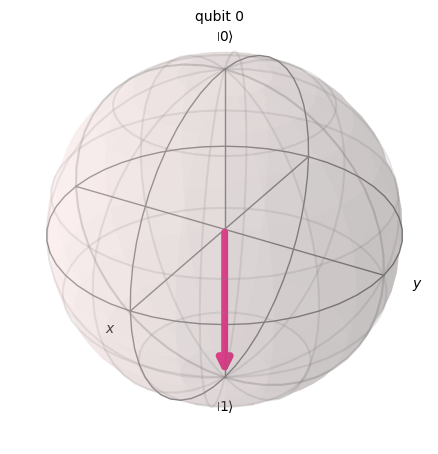

In [19]:
qc = QuantumCircuit(1)
qc.x(0)

print(qc)

state = Statevector.from_instruction(qc)
plot_bloch_multivector(state)


### Reflection
1. Did the state move from the north pole to the south pole?
2. Why can the X gate be thought of as a bit-flip gate?


In [ ]:
# Write your reflections for Task 6 here.


## Part 10: Apply H followed by Z

The **Z gate** changes phase. This is important because phase changes are not always obvious from measurement probabilities alone, but they still affect the Bloch Sphere representation.

### Task 7
Predict how the state will move after applying:
1. H
2. then Z


   ┌───┐┌───┐
q: ┤ H ├┤ Z ├
   └───┘└───┘


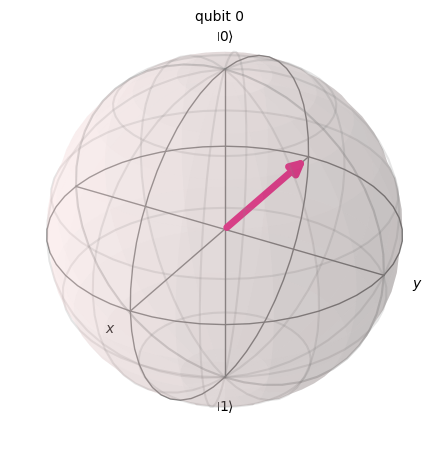

In [16]:
qc = QuantumCircuit(1)
qc.h(0)
qc.z(0)

print(qc)

state = Statevector.from_instruction(qc)
plot_bloch_multivector(state)


### Reflection
1. Did the point remain on the equator?
2. What changed after the Z gate?
3. Why is phase important in quantum computing?


In [ ]:
# Write your reflections for Task 7 here.


## Part 11: Compare a few gates

### Task 8
Run the next cell and compare the effect of different gates on the Bloch Sphere.



H
   ┌───┐
q: ┤ H ├
   └───┘


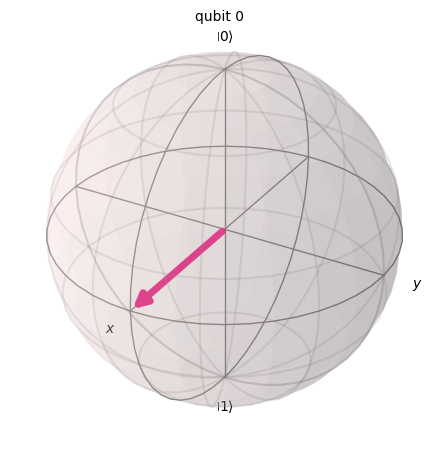


X
   ┌───┐
q: ┤ X ├
   └───┘


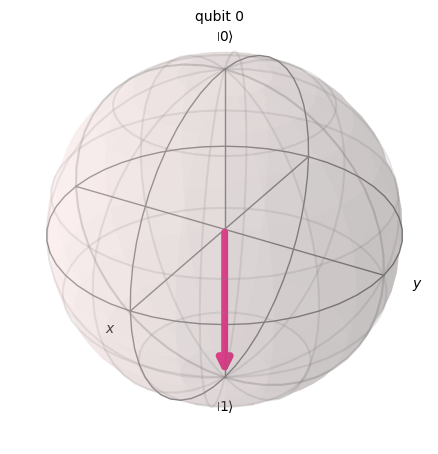


H then X
   ┌───┐┌───┐
q: ┤ H ├┤ X ├
   └───┘└───┘


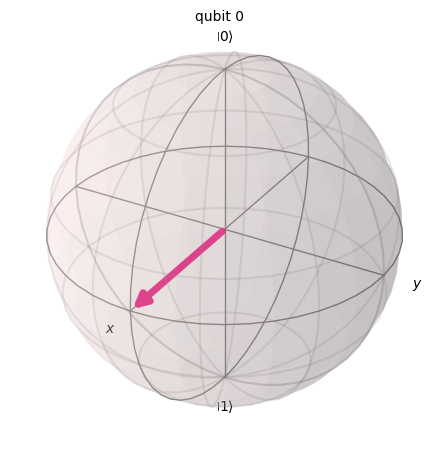


H then Z
   ┌───┐┌───┐
q: ┤ H ├┤ Z ├
   └───┘└───┘


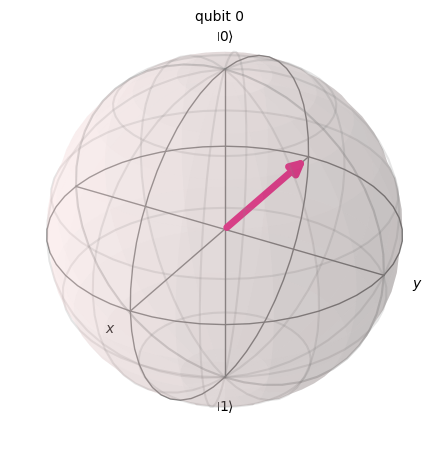


H then S
   ┌───┐┌───┐
q: ┤ H ├┤ S ├
   └───┘└───┘


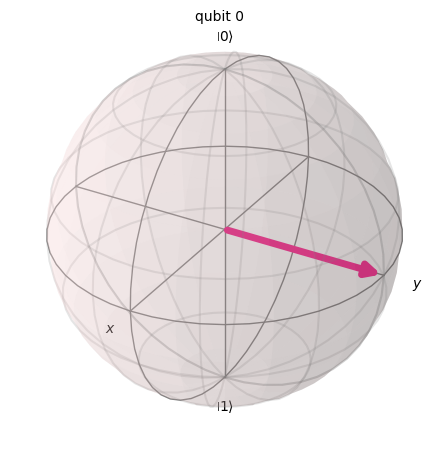

In [20]:
gate_sets = {
    "H": ["h"],
    "X": ["x"],
    "H then X": ["h", "x"],
    "H then Z": ["h", "z"],
    "H then S": ["h", "s"]
}

for name, gates in gate_sets.items():
    qc = QuantumCircuit(1)
    for gate in gates:
        getattr(qc, gate)(0)
    print(f"\n{name}")
    print(qc)
    state = Statevector.from_instruction(qc)
    display(plot_bloch_multivector(state))


### Reflection
Choose any **two** gate sequences above and explain:
- where the state ended up
- whether the move looked like a flip or a rotation
- what you learned from the comparison


In [ ]:
# Write your reflections for Task 8 here.


## Part 12: Student mini-challenge

### Task 9
Create your own **one-qubit** circuit using one or more of the following gates:

- `x`
- `y`
- `z`
- `h`
- `s`
- `t`

#### Instructions
1. Write your prediction in a comment.
2. Build the circuit.
3. Plot the Bloch Sphere.
4. Compare the result with your prediction.


   ┌───┐┌───┐
q: ┤ H ├┤ S ├
   └───┘└───┘


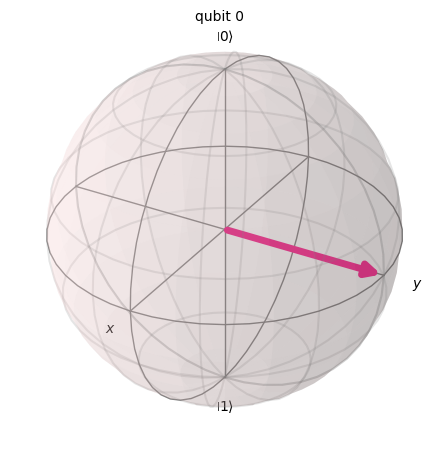

In [18]:
# Example template for your own circuit

qc = QuantumCircuit(1)

# Prediction:
# I think this circuit will ...

# Add your own gates here
qc.h(0)
qc.s(0)

print(qc)

state = Statevector.from_instruction(qc)
plot_bloch_multivector(state)


### Reflection
Describe:
1. the gates you used
2. what you predicted
3. what actually happened
4. whether the result matched your expectation


In [ ]:
# Write your reflections for Task 9 here.


## Part 13: Final summary questions

Answer the following in your own words:

1. What does the Bloch Sphere help us visualize?
2. What is the difference between basis states and superposition states on the sphere?
3. Which gate in this activity caused a clear flip between poles?
4. Which gate sequence helped you understand phase?
5. Why is the Bloch Sphere mainly useful for single-qubit states?


In [ ]:
# Write your final summary answers here.


## Optional extension

Try changing the code to test:

- `Y` gate
- `T` gate
- `H` then `S` then `Z`
- a circuit that returns the qubit back to $|0\rangle$

Then explain what happened on the Bloch Sphere.


## Instructor note

This notebook is designed as a guided activity, not just a demonstration.

A good teaching approach is:
- ask students to **predict first**
- let them **run the code**
- then ask them to **explain the movement** in simple words

That sequence helps them connect the **mathematics**, the **code**, and the **visual intuition** of the Bloch Sphere.
